**Import Libraries**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the dataset using Pandas.**

In [19]:
df = pd.read_csv('Palmer Penguins Dataset.csv')
df.head(20)
df.columns
#columns = ['species', 'island', 'bill_length_mm', 'bill_depth_mm','flipper_length_mm', 'body_mass_g', 'sex', 'year']
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [20]:
df.dropna(thresh=5,inplace=True)
df.drop_duplicates(inplace=True)
for col in df.columns:
    if df[col].dtype == 'object' :
        df[col] = df[col].str.strip().str.lower().str.replace(' ', '')
df.isnull().sum()
df.fillna({ 'bill_length_mm':df['bill_length_mm'].mean(),
            'bill_depth_mm':df['bill_depth_mm'].mean(),
            'flipper_length_mm':df['flipper_length_mm'].median(),
            'body_mass_g':df['body_mass_g'].median(),
            'sex': df['sex'].mode()[0]
            #'sex': 'unkown'
}, inplace=True)
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0
year,0


**Exploratory Data Analysis (EDA):**

In [21]:
print(df.describe())
print("\n--- Unique values per column ---")

for col in df.columns:
    print(f"Column '{col}' has {df[col].unique()} unique values.")
    print("--------------------------------"*3)

for col in df.columns:
    if df[col].dtype in ['float64', 'int64'] :
        print(f"Maximum and Minimum values of the Column '{col}'are : {df[col].max()}, {df[col].min()}\n Range of this column is [{df[col].max()}, {df[col].min()}]")

# for col in df.columns:
#     if df[col].dtype == 'object' :
#         print(f"Column '{col}' unique values: {df[col].unique()}")
#     else:
#         print(f"Column '{col}' has {df[col].unique()} unique numerical values.")
# print("--------------------------------")

       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
count      342.000000     342.000000         342.000000   342.000000   
mean        43.921930      17.151170         200.915205  4201.754386   
std          5.459584       1.974793          14.061714   801.954536   
min         32.100000      13.100000         172.000000  2700.000000   
25%         39.225000      15.600000         190.000000  3550.000000   
50%         44.450000      17.300000         197.000000  4050.000000   
75%         48.500000      18.700000         213.000000  4750.000000   
max         59.600000      21.500000         231.000000  6300.000000   

              year  
count   342.000000  
mean   2008.029240  
std       0.817168  
min    2007.000000  
25%    2007.000000  
50%    2008.000000  
75%    2009.000000  
max    2009.000000  

--- Unique values per column ---
Column 'species' has ['adelie' 'gentoo' 'chinstrap'] unique values.
------------------------------------------------------------

#**Visualization Tasks:**


species
adelie       151
gentoo       123
chinstrap     68
Name: count, dtype: int64


Text(0, 0.5, 'length of species')

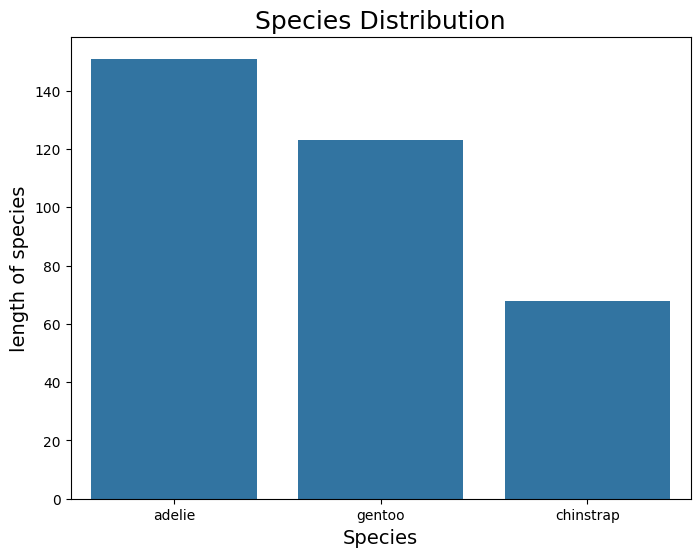

In [22]:
#Species Distribution
species_counts = df['species'].value_counts()
print(species_counts)
plt.figure(figsize=(8, 6))
sns.barplot(x=species_counts.index, y=species_counts.values)
plt.title('Species Distribution', fontsize=18)
plt.xlabel('Species', fontsize=14)
plt.ylabel('length of species', fontsize=14)
#sns.countplot(x="species", data=df, palette="Set2")

From this distribution we can conclude that : Adelie penguins are the most common, followed by Gentoo, then Chinstrap.

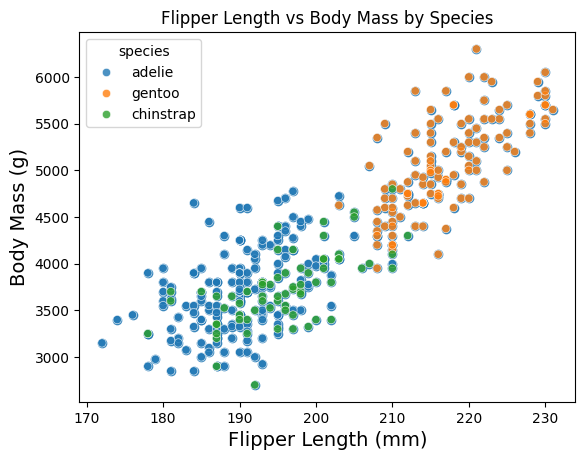

In [23]:
#Scatter using Matplotlib
df.columns
plt.scatter(df['flipper_length_mm'], df['body_mass_g'], alpha = 0.8 )
plt.title('Flipper Length vs. Body Mass', fontsize=16)
plt.xlabel('Flipper Length (mm)', fontsize=14)
plt.ylabel('Body Mass (g)', fontsize=14)

#scatter using seaborn
sns.scatterplot( data=df, x='flipper_length_mm', y='body_mass_g', hue='species', alpha=0.8)
plt.title("Flipper Length vs Body Mass by Species")
plt.show()


**Gentoo penguins** are significantly heavier and have longer flippers.

**Adelie** and **Chinstrap** overlap, sometimes show distinct clusters.

The figure show positive correlation: heavier penguins tend to have longer flippers.

island
biscoe       167
dream        124
torgersen     51
Name: count, dtype: int64


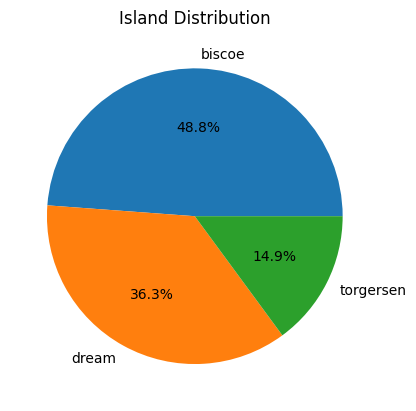

In [24]:
#Island Distribution:
penguins_count = df['island'].value_counts()
print(penguins_count)
plt.pie(penguins_count, labels=penguins_count.index, autopct='%1.1f%%')
plt.title('Island Distribution')
plt.show()

#we can replace 2 lines of code with this
#df['island'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette("pastel"))

Biscoe island hosts the majority of the panguins folowed by Dream island then island.

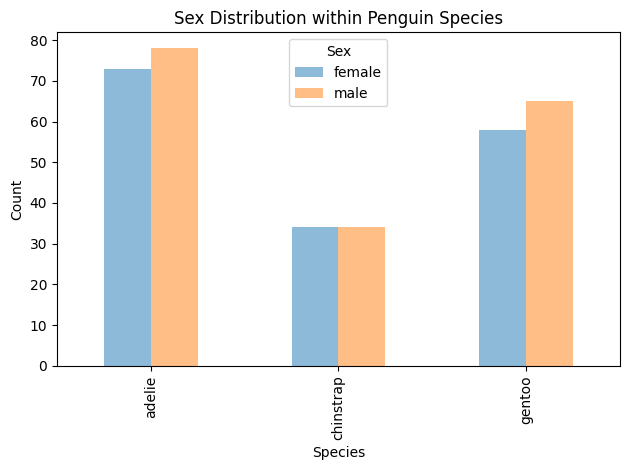

In [25]:
sex_counts = df.groupby(['species', 'sex']).size().unstack()
sex_counts.plot(kind='bar', alpha = 0.5)
#sns.countplot(x="species", hue="sex", data=df, palette="coolwarm")
plt.title("Sex Distribution within Penguin Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.legend(title="Sex")
plt.tight_layout()
plt.show()

Adelie shows a balanced male/female count. While Chinstrap and Gentoo may have slight difference.

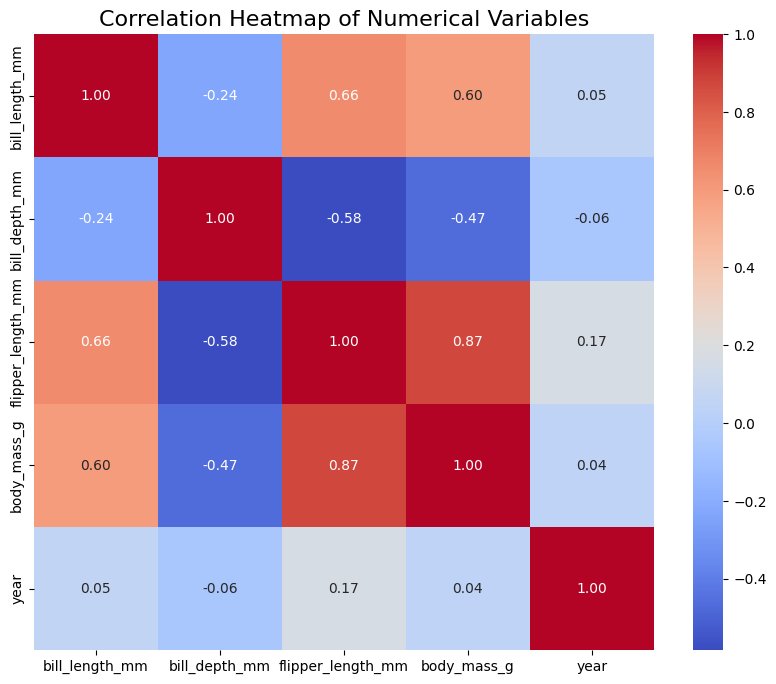

In [26]:
#Heatmap
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
#sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16)
plt.show()

Positive correlation between flipper length and body mass, and between bill length and flipper length

Negative correlation between bill depth and bill length, and between bill depth and bill length

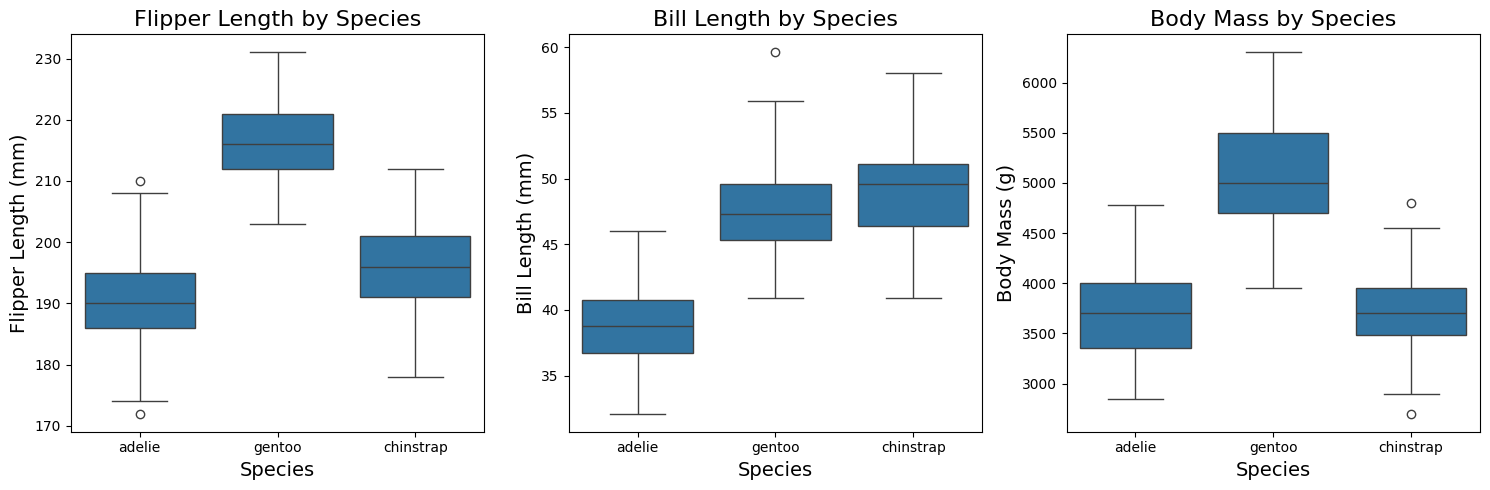

In [27]:
#Boxplots for Measurements: Generate boxplots for flipper length, body mass, and bill measurements, segmented by species.
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df, x='species', y='flipper_length_mm', ax=a1)
a1.set_title('Flipper Length by Species', fontsize=16)
a1.set_xlabel('Species', fontsize=14)
a1.set_ylabel('Flipper Length (mm)', fontsize=14)
sns.boxplot(data=df, x='species', y='bill_length_mm', ax=a2)
a2.set_title('Bill Length by Species', fontsize=16)
a2.set_xlabel('Species', fontsize=14)
a2.set_ylabel('Bill Length (mm)', fontsize=14)
sns.boxplot(data=df, x='species', y='body_mass_g', ax=a3)
a3.set_title('Body Mass by Species', fontsize=16)
a3.set_xlabel('Species', fontsize=14)
a3.set_ylabel('Body Mass (g)', fontsize=14)
plt.tight_layout()
plt.show()

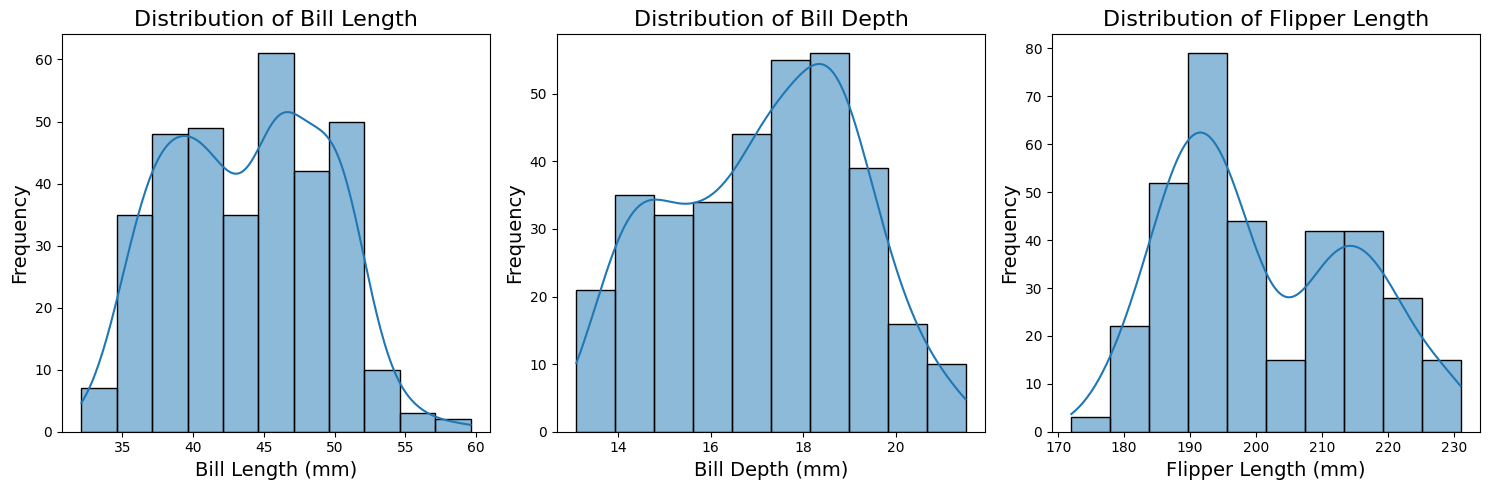

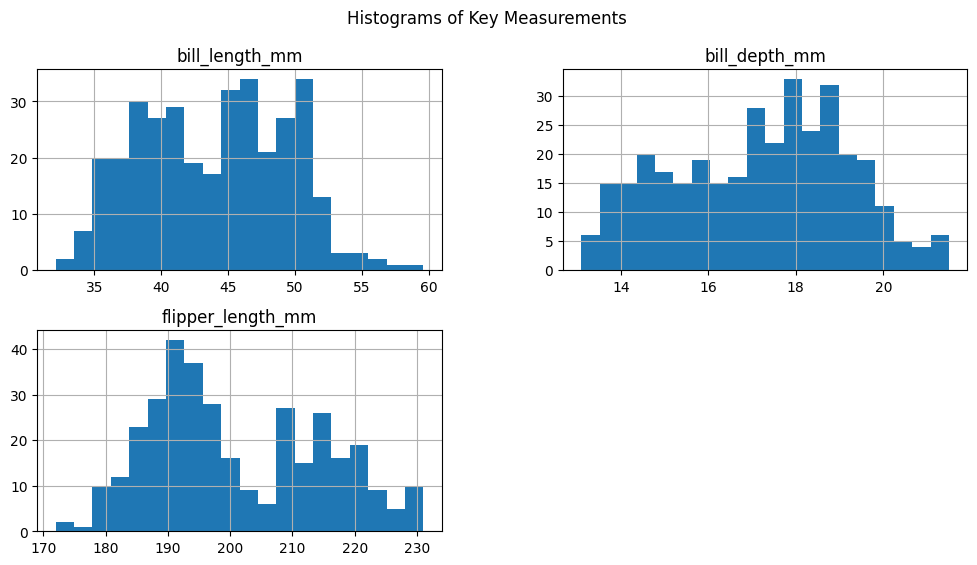

In [28]:
#Histograms of Measurements:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(data=df, x='bill_length_mm', kde=True, ax=a1)
a1.set_title('Distribution of Bill Length', fontsize=16)
a1.set_xlabel('Bill Length (mm)', fontsize=14)
a1.set_ylabel('Frequency', fontsize=14)

sns.histplot(data=df, x='bill_depth_mm', kde=True, ax=a2)
a2.set_title('Distribution of Bill Depth', fontsize=16)
a2.set_xlabel('Bill Depth (mm)', fontsize=14)
a2.set_ylabel('Frequency', fontsize=14)

sns.histplot(data=df, x='flipper_length_mm', kde=True, ax=a3)
a3.set_title('Distribution of Flipper Length', fontsize=16)
a3.set_xlabel('Flipper Length (mm)', fontsize=14)
a3.set_ylabel('Frequency', fontsize=14)

plt.tight_layout()
plt.show()

df[['bill_length_mm','bill_depth_mm','flipper_length_mm']].hist(figsize=(12,6), bins=20)
plt.suptitle("Histograms of Key Measurements")
plt.show()

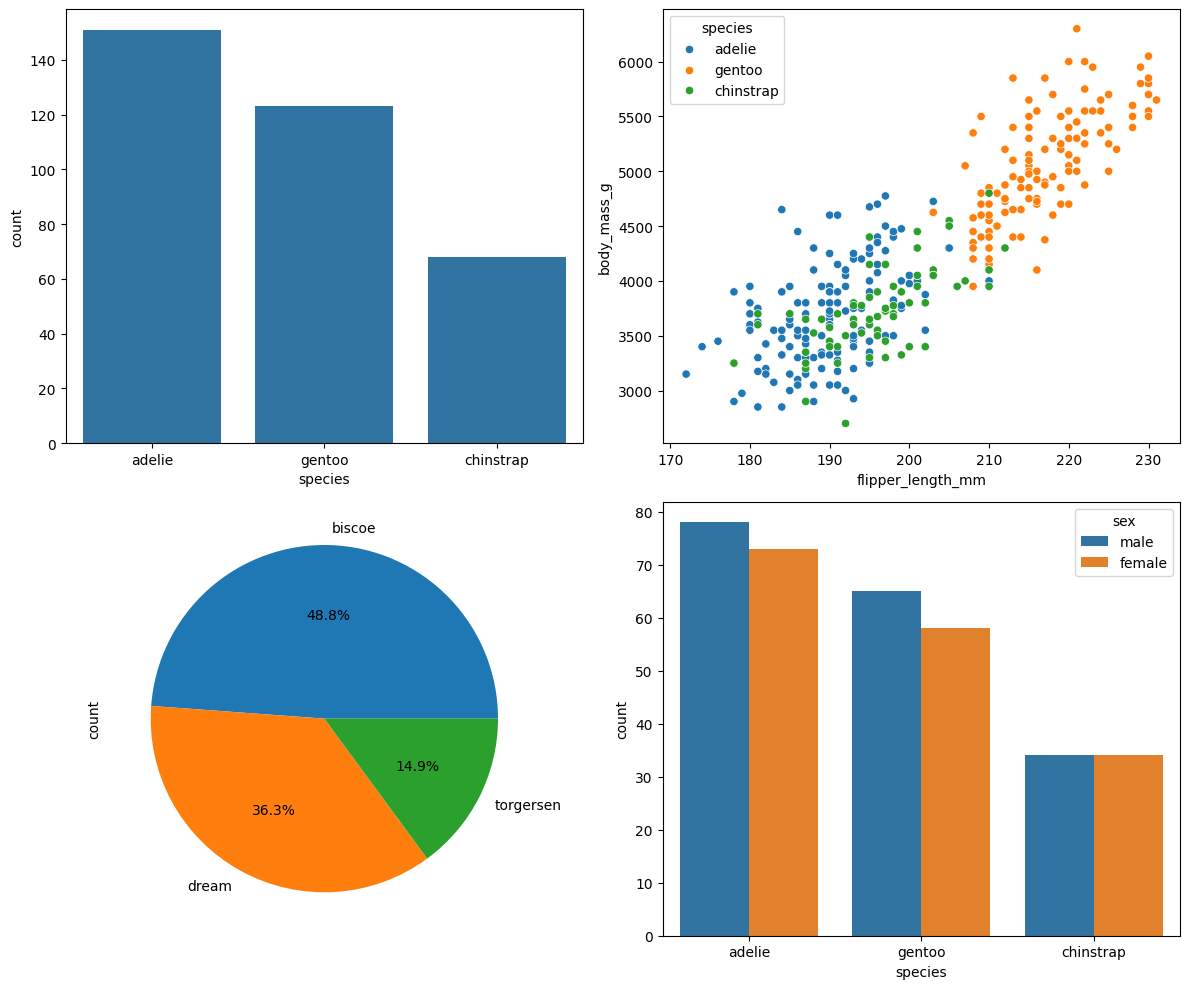

In [29]:
fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.countplot(x="species", data=df, ax=axes[0,0])
sns.scatterplot(x="flipper_length_mm", y="body_mass_g", hue="species", data=df, ax=axes[0,1])
df['island'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,0])
sns.countplot(x="species", hue="sex", data=df, ax=axes[1,1])

plt.tight_layout()
plt.show()


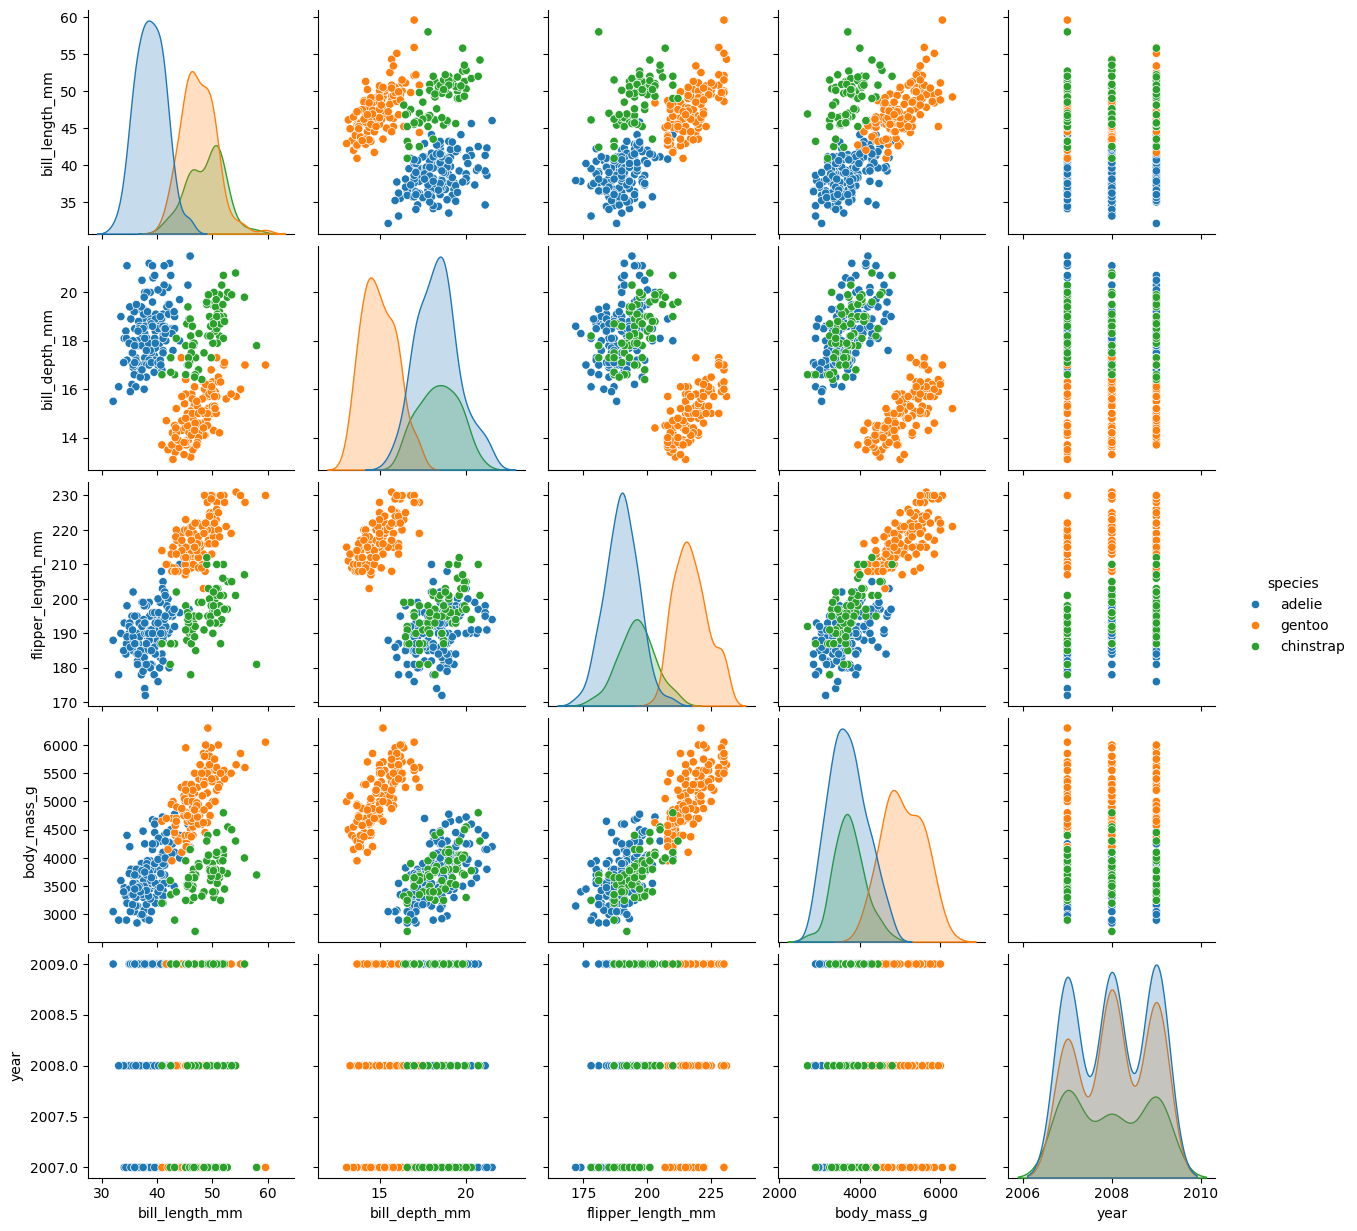

In [30]:
sns.pairplot(df, hue="species")
plt.show()

**Conclusion**
Physical traits are highly informative for distinguishing penguin species.

Certain features (flipper length, body mass, bill dimensions) are strong predictors.

In [31]:
# # Aggregate by species
# df_grouped = df.groupby('species')[['flipper_length_mm', 'body_mass_g', 'bill_depth_mm']].mean()

# plt.figure(figsize=(16, 8))
# width = 0.25
# x = np.arange(len(df_grouped))

# # Bars
# b1 = plt.bar(x - width, df_grouped['flipper_length_mm'], width, label='Flipper Length', color="#d62728")
# b2 = plt.bar(x, df_grouped['body_mass_g'], width, label='Body Mass', color="#2ca02c")
# b3 = plt.bar(x + width, df_grouped['bill_depth_mm'], width, label='Bill Depth', color="#9467bd")

# plt.xticks(x, df_grouped.index)   # Label x-axis with species names
# plt.legend()
# plt.show()


# # Aggregate by species (re-calculate to ensure it's fresh, though it was correct)
# df_grouped = df.groupby('species')[['flipper_length_mm', 'body_mass_g', 'bill_depth_mm']].mean()

# fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

# # Plot Flipper Length
# sns.barplot(x=df_grouped.index, y=df_grouped['flipper_length_mm'], ax=axes[0])
# axes[0].set_title('Mean Flipper Length by Species')
# axes[0].set_ylabel('Flipper Length (mm)')
# axes[0].set_xlabel('Species')

# # Plot Body Mass
# sns.barplot(x=df_grouped.index, y=df_grouped['body_mass_g'], ax=axes[1])
# axes[1].set_title('Mean Body Mass by Species')
# axes[1].set_ylabel('Body Mass (g)')
# axes[1].set_xlabel('Species')

# # Plot Bill Depth
# sns.barplot(x=df_grouped.index, y=df_grouped['bill_depth_mm'], ax=axes[2])
# axes[2].set_title('Mean Bill Depth by Species')
# axes[2].set_ylabel('Bill Depth (mm)')
# axes[2].set_xlabel('Species')

# plt.tight_layout()
# plt.show()